# Data Preprocessing - Lung Cancer Dataset

This notebook handles data loading, exploration, and preprocessing for the Lung Cancer dataset (50,000 samples, 23 features, 3-class target).

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('./data/lung_cancer_clean_50k.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (50000, 26)

Columns: ['index', 'Patient Id', 'Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring', 'Level']

First few rows:


,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,102,P190,49,1,6,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,2
1,435,P490,49,1,6,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,2
2,860,P873,36,2,2,1,5,3,2,3,...,6,7,2,5,8,1,3,2,3,1
3,270,P341,24,2,1,2,2,3,2,4,...,1,1,1,2,3,4,5,2,1,0
4,106,P194,33,1,6,7,7,7,7,7,...,8,5,7,6,7,8,7,6,2,2


## 3. Data Exploration

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print(f"\n\nDataset info:")
df.info()

Missing values:
index                       0
Patient Id                  0
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Level                       0
dtype: int64


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype
---  ------             

Target distribution (Level):
Level
0    15114
1    16454
2    18432
Name: count, dtype: int64

Percentage:
Level
0    30.228
1    32.908
2    36.864
Name: proportion, dtype: float64


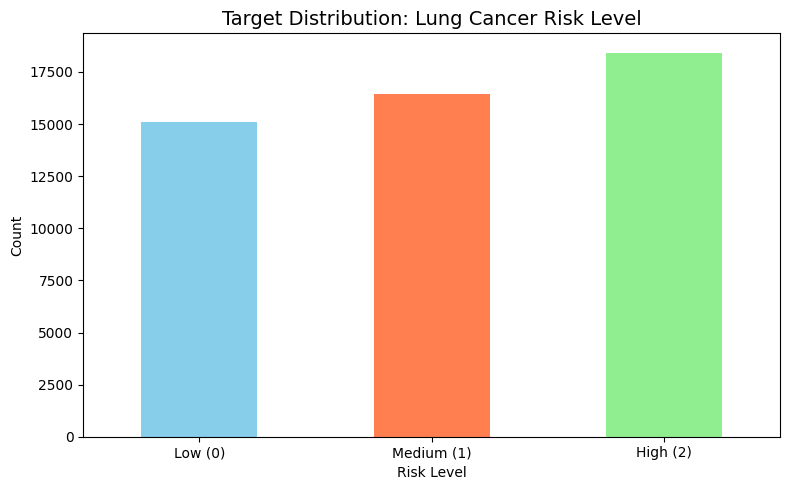

In [4]:
# Target distribution
print("Target distribution (Level):")
print(df['Level'].value_counts().sort_index())
print(f"\nPercentage:")
print(df['Level'].value_counts(normalize=True).sort_index() * 100)

# Visualize target distribution
plt.figure(figsize=(8, 5))
counts = df['Level'].value_counts().sort_index()
counts.plot(kind='bar', color=['skyblue', 'coral', 'lightgreen'])
plt.title('Target Distribution: Lung Cancer Risk Level', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Low (0)', 'Medium (1)', 'High (2)'], rotation=0)
plt.tight_layout()
plt.show()

In [5]:
# Statistical summary
print("Statistical summary:")
df.describe()

Statistical summary:


,index,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,501.943360,37.129200,1.400880,3.856020,4.569120,5.167040,4.839500,4.586040,4.385520,4.493880,...,3.859360,3.85882,4.247880,3.776900,3.740960,3.923300,3.536160,3.859020,2.918980,1.066360
std,289.067217,11.961718,0.490082,2.027672,2.618267,1.980923,2.112503,2.125617,1.849617,2.136617,...,2.255864,2.21020,2.289432,2.041472,2.271969,2.383982,1.830923,2.038212,1.472161,0.816413
min,0.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,252.000000,27.000000,1.000000,2.000000,2.000000,4.000000,3.000000,2.000000,3.000000,2.000000,...,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000
50%,505.000000,36.000000,1.000000,3.000000,5.000000,6.000000,5.000000,5.000000,4.000000,4.000000,...,3.000000,3.00000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,1.000000
75%,753.000000,45.000000,2.000000,6.000000,7.000000,7.000000,7.000000,7.000000,6.000000,7.000000,...,5.000000,6.00000,6.000000,5.000000,5.000000,5.000000,5.000000,6.000000,4.000000,2.000000
max,999.000000,73.000000,2.000000,8.000000,8.000000,8.000000,8.000000,7.000000,7.000000,7.000000,...,9.000000,8.00000,9.000000,8.000000,8.000000,9.000000,7.000000,7.000000,7.000000,2.000000


## 4. Feature Selection & Preprocessing

In [6]:
# Drop non-feature columns (index and Patient Id are identifiers, not features)
drop_cols = ['index', 'Patient Id']
df_clean = df.drop(columns=drop_cols, errors='ignore')

# Separate features and target
X = df_clean.drop('Level', axis=1)
y = df_clean['Level']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())
print(f"\nTarget classes: {sorted(y.unique())}")

Features shape: (50000, 23)
Target shape: (50000,)

Feature columns (23):
['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']

Target classes: [np.int64(0), np.int64(1), np.int64(2)]


In [7]:
# Split the data: 80% train, 20% test (stratified to maintain class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")
print(f"\nTraining set target distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest set target distribution:")
print(y_test.value_counts().sort_index())

Training set size: 40,000 samples
Test set size: 10,000 samples

Training set target distribution:
Level
0    12091
1    13163
2    14746
Name: count, dtype: int64

Test set target distribution:
Level
0    3023
1    3291
2    3686
Name: count, dtype: int64


## 5. Feature Scaling

In [8]:
# Initialize MinMaxScaler(feature_range=(-1, 1))
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

# Verify scaling bounds
print(f"\nScaled training data statistics:")
print(f"Min: {X_train_scaled.min(axis=0)[:5]}...")
print(f"Max: {X_train_scaled.max(axis=0)[:5]}...")

Scaled training data shape: (40000, 23)
Scaled test data shape: (10000, 23)

Scaled training data statistics:
Min: [-1. -1. -1. -1. -1.]...
Max: [1. 1. 1. 1. 1.]...


In [9]:
# Theoretical bounds from MinMaxScaler: every feature is in [-1, 1]
n_features = X_train_scaled.shape[1]
lower_bound = np.full(n_features, -1.0)
upper_bound = np.full(n_features, 1.0)
bounds = (lower_bound, upper_bound)
print(f"Theoretical feature bounds (data-independent):")
print(f"  Lower: [-1.0] × {n_features} features")
print(f"  Upper: [+1.0] × {n_features} features")


Theoretical feature bounds (data-independent):
  Lower: [-1.0] × 23 features
  Upper: [+1.0] × 23 features


## 6. Save Preprocessed Data

In [10]:
# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Save as pickle file
processed_data = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train.values,
    'y_test': y_test.values,
    'feature_names': X.columns.tolist(),
    'bounds': bounds,
    'scaler': scaler,
    'n_classes': 3,
    'class_names': ['Low (0)', 'Medium (1)', 'High (2)']
}

with open('data/processed_data.pkl', 'wb') as f:
    pickle.dump(processed_data, f)

print("✓ Preprocessed data saved to 'data/processed_data.pkl'")
print(f"\nSaved objects:")
print(f"  - X_train: {X_train_scaled.shape}")
print(f"  - X_test: {X_test_scaled.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")
print(f"  - feature_names: {len(X.columns)} features")
print(f"  - bounds: lower and upper bounds for DP")
print(f"  - scaler: MinMaxScaler object")
print(f"  - n_classes: 3 (Low / Medium / High)")

✓ Preprocessed data saved to 'data/processed_data.pkl'

Saved objects:
  - X_train: (40000, 23)
  - X_test: (10000, 23)
  - y_train: (40000,)
  - y_test: (10000,)
  - feature_names: 23 features
  - bounds: lower and upper bounds for DP
  - scaler: MinMaxScaler object
  - n_classes: 3 (Low / Medium / High)


## 7. Correlation Heatmap

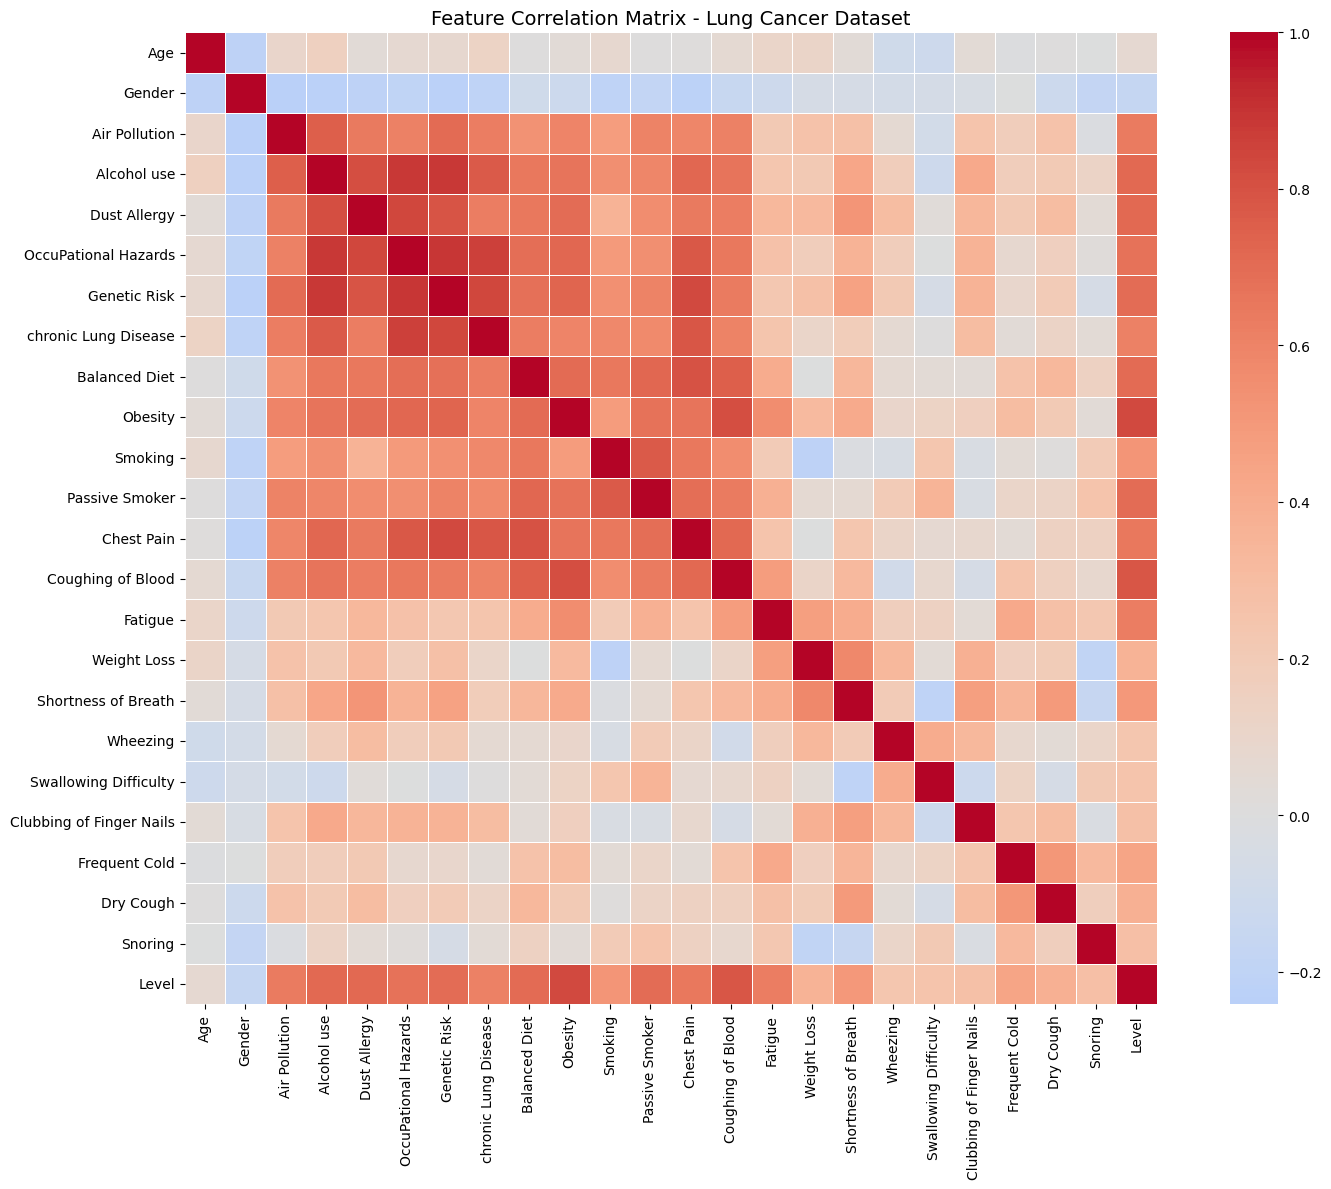

In [11]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix - Lung Cancer Dataset', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
print("="*60)
print("DATA PREPROCESSING SUMMARY")
print("="*60)
print(f"Dataset: Lung Cancer Dataset")
print(f"Total samples: {df.shape[0]:,}")
print(f"Features: {X.shape[1]}")
print(f"Classes: 3 (Low=0, Medium=1, High=2)")
print(f"\nTrain-Test Split (80/20, stratified):")
print(f"  Training: {X_train.shape[0]:,} samples")
print(f"  Test: {X_test.shape[0]:,} samples")
print(f"\nPreprocessing:")
print(f"  ✓ Dropped identifier columns (index, Patient Id)")
print(f"  ✓ MinMaxScaler applied (range=[-1, 1])")
print(f"  ✓ Feature bounds computed for DP")
print(f"  ✓ Data saved to pickle file")
print(f"\nReady for model training!")
print("="*60)

DATA PREPROCESSING SUMMARY
Dataset: Lung Cancer Dataset
Total samples: 50,000
Features: 23
Classes: 3 (Low=0, Medium=1, High=2)

Train-Test Split (80/20, stratified):
  Training: 40,000 samples
  Test: 10,000 samples

Preprocessing:
  ✓ Dropped identifier columns (index, Patient Id)
  ✓ MinMaxScaler applied (range=[-1, 1])
  ✓ Feature bounds computed for DP
  ✓ Data saved to pickle file

Ready for model training!
